# HER
이 튜토리얼은 **Hindsight Experience Replay (HER)**를 구현하는 방법을 안내한다.

**HER (Hindsight Experience Replay)**는 로봇 팔 제어와 같이 희소한 보상(Sparse Reward)을 주는 환경에서 매우 효과적인 기법이다. 에이전트가 목표를 달성하지 못했더라도, **"도달한 그 상태가 원래 목표였다면 성공한 것이다"**라고 가정하여 보상을 재계산하고 학습한다. 즉, **실패로부터 배우는 알고리즘**이다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`, `gymnasium-robotics`, `torch`를 사용하여 **SAC (Soft Actor-Critic) + HER**를 구현한다. 환경은 `FetchReach-v2`를 사용한다.

### 1. 라이브러리 설치 및 가상 디스플레이 설정

로봇 환경(`FetchReach`)을 사용하기 위해 `gymnasium-robotics`를 추가로 설치한다.

In [9]:
# 최신 파이썬 라이브러리 설치
# gymnasium-robotics: 로봇 팔 환경 포함
%pip install -q gymnasium[box2d] gymnasium-robotics pyvirtualdisplay imageio

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
Note: you may need to restart the kernel to use updated packages.


In [24]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트

학습에 필요한 라이브러리를 불러온다.

In [25]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions.normal import Normal
from collections import deque
import gymnasium as gym
import gymnasium_robotics
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수

학습된 에이전트의 동작을 확인하기 위한 함수다.

In [26]:
def display_video(video_path):
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Actor & Critic 네트워크 생성

HER는 알고리즘 자체가 아니라 **데이터를 사용하는 방식**이다. 따라서 기본 알고리즘으로는 **SAC**를 사용한다.
네트워크의 입력은 **상태(Observation)와 목표(Goal)를 결합(Concatenate)**한 벡터가 된다.

In [27]:
class Actor(nn.Module):
    def __init__(self, input_dim, hidden_size, action_dim, max_action):
        """
        Actor: (상태 + 목표) -> 행동 분포 (Mean, Std)
        """
        super().__init__()
        self.max_action = float(max_action)

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        self.mean_layer = nn.Linear(hidden_size, action_dim)
        self.log_std_layer = nn.Linear(hidden_size, action_dim)

    def forward(self, state_goal):
        x = self.net(state_goal)
        mean = self.mean_layer(x)
        log_std = self.log_std_layer(x)
        log_std = torch.clamp(log_std, -20, 2)
        std = torch.exp(log_std)

        dist = Normal(mean, std)
        z = dist.rsample() # Reparameterization Trick
        action = torch.tanh(z)

        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        return action * self.max_action, log_prob

class SoftQNetwork(nn.Module):
    def __init__(self, input_dim, hidden_size, action_dim):
        """
        Critic: (상태 + 목표) + 행동 -> Q값
        """
        super().__init__()

        # Q1
        self.net1 = nn.Sequential(
            nn.Linear(input_dim + action_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

        # Q2
        self.net2 = nn.Sequential(
            nn.Linear(input_dim + action_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state_goal, action):
        x = torch.cat([state_goal, action], dim=1)
        return self.net1(x), self.net2(x)

### 5. HER 리플레이 버퍼 (HER Replay Buffer)

HER의 핵심이다. 일반적인 버퍼와 달리 **전체 에피소드**를 저장한다.
배치를 샘플링할 때, 일정 확률(`her_ratio`)로 원래의 목표(`desired_goal`) 대신, 에피소드 내의 미래 시점에 실제로 도달한 상태(`achieved_goal`)를 목표로 대체하여 보상을 재계산한다. 이를 **Future Strategy**라고 한다.

In [28]:
class HERReplayBuffer:
    def __init__(self, capacity, env, her_ratio=0.8):
        self.buffer = deque(maxlen=capacity)
        self.env = env
        self.her_ratio = her_ratio # Goal을 바꿀 확률 (미래 시점의 달성 상태로)

    def __len__(self):
        return len(self.buffer)

    def append(self, episode_trajectory):
        """에피소드 전체 궤적을 저장한다."""
        self.buffer.append(episode_trajectory)

    def sample(self, batch_size):
        # 1. 에피소드 인덱스 선택
        indices = np.random.randint(0, len(self.buffer), batch_size)

        states, actions, next_states = [], [], []
        desired_goals, achieved_goals = [], []
        rewards = []  # <--- 이 줄이 누락되었습니다! 추가해 주세요.

        for idx in indices:
            episode = self.buffer[idx]

            # 2. 에피소드 내에서 현재 타임스텝(t) 선택
            t = np.random.randint(0, len(episode))
            transition = episode[t]

            obs = transition['obs']
            action = transition['action']
            next_obs = transition['next_obs']
            goal = transition['desired_goal']

            # 3. HER 적용 여부 결정 (Future Strategy)
            if np.random.random() < self.her_ratio:
                future_t = np.random.randint(t, len(episode))
                future_transition = episode[future_t]
                goal = future_transition['achieved_goal']

            # 4. 보상 재계산 (unwrapped 사용)
            reward = self.env.unwrapped.compute_reward(transition['achieved_goal'], goal, {})

            states.append(obs)
            actions.append(action)
            next_states.append(next_obs)
            desired_goals.append(goal)
            rewards.append(reward) # <--- 계산된 보상을 리스트에 추가!

        # 배열 변환 및 결합
        states = np.array(states)
        next_states = np.array(next_states)
        desired_goals = np.array(desired_goals)
        actions = np.array(actions)
        rewards = np.array(rewards).reshape(-1, 1) # 이제 에러가 나지 않습니다.
        dones = np.zeros_like(rewards)

        # 입력 벡터 구성
        inp_states = np.concatenate([states, desired_goals], axis=1)
        inp_next_states = np.concatenate([next_states, desired_goals], axis=1)

        return inp_states, actions, rewards, dones, inp_next_states

### 6. Pytorch Wrapper 클래스 (SAC + HER 구현)

에피소드를 수집하고, HER 버퍼를 통해 학습하는 전체 과정을 관리한다.

* `play_episode`: 한 에피소드를 끝까지 실행하고 전체 궤적을 버퍼에 저장한다.
* `train_step`: HER 버퍼에서 데이터를 샘플링하여 SAC 업데이트를 수행한다.

In [29]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=256, lr=1e-3,
                 capacity=1000000, gamma=0.98, batch_size=256, tau=0.005, alpha=0.2):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.alpha = alpha

        # 환경 생성 (gymnasium-robotics)
        self.env = gym.make(env_name, render_mode='rgb_array')

        # 상태 및 행동 차원 확인
        # Dict Observation: 'observation', 'desired_goal', 'achieved_goal'
        obs_dim = self.env.observation_space['observation'].shape[0]
        goal_dim = self.env.observation_space['desired_goal'].shape[0]
        input_dim = obs_dim + goal_dim # 네트워크 입력은 상태 + 목표

        action_dim = self.env.action_space.shape[0]
        max_action = self.env.action_space.high[0]

        # 네트워크 초기화
        self.actor = Actor(input_dim, hidden_size, action_dim, max_action).to(device)
        self.critic = SoftQNetwork(input_dim, hidden_size, action_dim).to(device)
        self.critic_target = copy.deepcopy(self.critic).to(device)

        # 최적화기
        self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=lr)
        self.critic_optimizer = optim.AdamW(self.critic.parameters(), lr=lr)

        # HER 버퍼
        self.buffer = HERReplayBuffer(capacity, self.env)

    def get_action(self, obs, goal):
        """행동 선택"""
        # 상태와 목표를 결합
        inp = np.concatenate([obs, goal])
        state_t = torch.tensor(np.array([inp]), dtype=torch.float32, device=device)

        with torch.no_grad():
            action, _ = self.actor(state_t)

        return action.cpu().numpy()[0]

    def soft_update(self, net, target_net):
        for param, target_param in zip(net.parameters(), target_net.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

    def play_episode(self):
        """
        에피소드를 실행하고 궤적(Trajectory)을 저장
        """
        obs_dict, _ = self.env.reset()
        obs = obs_dict['observation']
        desired_goal = obs_dict['desired_goal']

        episode_trajectory = []
        done = False
        truncated = False
        episode_reward = 0

        while not (done or truncated):
            action = self.get_action(obs, desired_goal)
            next_obs_dict, reward, done, truncated, info = self.env.step(action)

            next_obs = next_obs_dict['observation']
            achieved_goal = next_obs_dict['achieved_goal'] # 현재 달성한 상태 (HER에서 중요)

            # 궤적 저장 (obs, action, next_obs, desired_goal, achieved_goal)
            episode_trajectory.append({
                'obs': obs,
                'action': action,
                'next_obs': next_obs,
                'desired_goal': desired_goal,
                'achieved_goal': achieved_goal
            })

            obs = next_obs
            episode_reward += reward

        # 에피소드 전체를 버퍼에 저장
        self.buffer.append(episode_trajectory)

        return episode_reward, info['is_success']

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return

        # HER 버퍼에서 샘플링 (여기서 목표 교체 및 보상 재계산이 일어남)
        states, actions, rewards, dones, next_states = self.buffer.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32, device=device)
        actions = torch.tensor(actions, dtype=torch.float32, device=device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=device)

        # SAC Update Logic
        # 1. Critic Update
        with torch.no_grad():
            next_actions, next_log_probs = self.actor(next_states)
            target_q1, target_q2 = self.critic_target(next_states, next_actions)
            target_q = torch.min(target_q1, target_q2) - self.alpha * next_log_probs
            y_target = rewards + (1 - dones) * self.gamma * target_q

        current_q1, current_q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(current_q1, y_target) + F.mse_loss(current_q2, y_target)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # 2. Actor Update
        new_actions, log_probs = self.actor(states)
        q1, q2 = self.critic(states, new_actions)
        actor_loss = (self.alpha * log_probs - torch.min(q1, q2)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # 3. Soft Update
        self.soft_update(self.critic, self.critic_target)

    def run_training(self, max_epochs=200, episodes_per_epoch=10, updates_per_epoch=40):
        success_rates = []

        for epoch in range(max_epochs):
            # 1. 에피소드 수집
            total_success = 0
            for _ in range(episodes_per_epoch):
                _, is_success = self.play_episode()
                total_success += is_success

            # 2. 학습 수행
            for _ in range(updates_per_epoch):
                self.train_step()

            success_rate = total_success / episodes_per_epoch
            success_rates.append(success_rate)

            if epoch % 5 == 0:
                print(f"Epoch {epoch}, Success Rate: {success_rate:.2f}")

        return success_rates

    def save_video(self, filename="her_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        obs_dict, _ = env.reset()
        done = False
        truncated = False

        while not (done or truncated):
            action = self.get_action(obs_dict['observation'], obs_dict['desired_goal'])
            obs_dict, _, done, truncated, _ = env.step(action)
        env.close()

### 7. 학습 실행 (Training)

로봇 팔이 목표 지점에 도달해야 하는 `FetchReach-v4` 환경에서 학습을 진행한다. 이 환경은 목표에 도달해야만 0점(성공), 그 외에는 -1점(실패)을 주는 희소 보상 환경이다. HER 없이는 학습이 매우 어렵다.

In [ ]:
# SAC + HER 모델 생성
# FetchReach는 비교적 쉬운 환경이므로 epoch를 적게 설정해도 금방 100%에 도달한다.
agent = PytorchWrapper(
    'FetchReach-v4',
    hidden_size=256,
    lr=1e-3,
    batch_size=256
)

# 학습 시작
print("SAC + HER 학습을 시작한다...")
history = agent.run_training(max_epochs=1000, episodes_per_epoch=10, updates_per_epoch=40)
print("학습 완료.")

SAC + HER 학습을 시작한다...
Epoch 0, Success Rate: 0.00
Epoch 5, Success Rate: 0.00
Epoch 10, Success Rate: 0.00
Epoch 15, Success Rate: 0.00
Epoch 20, Success Rate: 0.00
Epoch 25, Success Rate: 0.00
Epoch 30, Success Rate: 0.00
Epoch 35, Success Rate: 0.00
Epoch 40, Success Rate: 0.00
Epoch 45, Success Rate: 0.00
Epoch 50, Success Rate: 0.00
Epoch 55, Success Rate: 0.00


### 8. 결과 시각화 (Visualization)

성공률(Success Rate) 그래프와 에이전트의 영상을 확인한다.

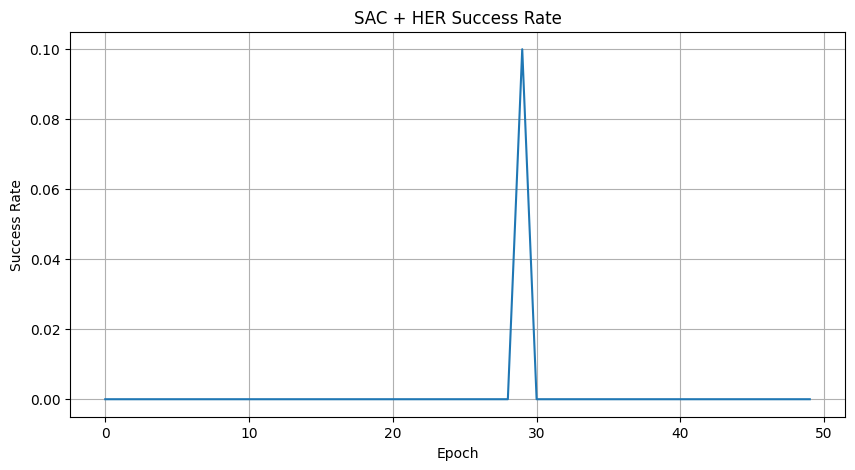

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [23]:
# 성공률 그래프
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("SAC + HER Success Rate")
plt.xlabel("Epoch")
plt.ylabel("Success Rate")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("sac-her")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")